In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading The Required Libraries**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

**Loading the dataset**

In [3]:
df = pd.read_csv('insurance.csv')

**Checking for null values in the dataset**

In [4]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Encoding smoker (yes,no) categorical to (0.1) numerical**

In [5]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})


**Same encoding for gender**

In [6]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})

In [7]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

**Processed Dataset**

In [8]:
print("\nProcessed Dataset:")
print(df.head())


Processed Dataset:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


**Visualization (Age VS Charges Scatter Plot)**

Text(0.5, 1.0, 'Impact of Age on Charges')

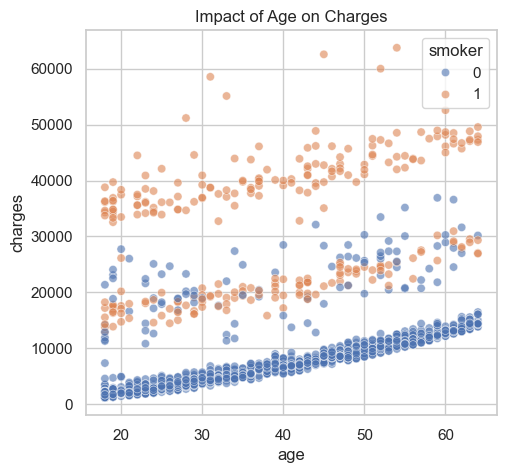

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Impact of Age on Charges')

**BMI VS Charges (Scatter Plot)**

Text(0.5, 1.0, 'Impact of BMI on Charges')

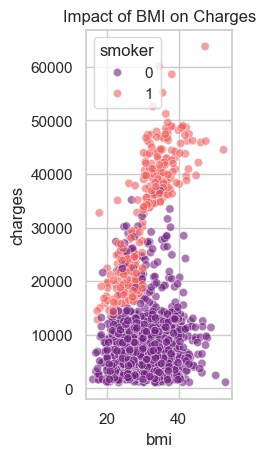

In [10]:

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='magma', alpha=0.6)
plt.title('Impact of BMI on Charges')

**Smoking VS Charges (Boxplot)**

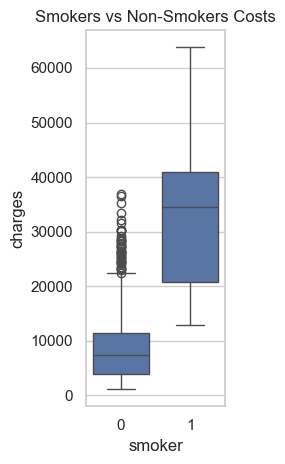

In [12]:

plt.subplot(1, 3, 3)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smokers vs Non-Smokers Costs')
plt.tight_layout()
plt.show()

**Correlation Heatmap**

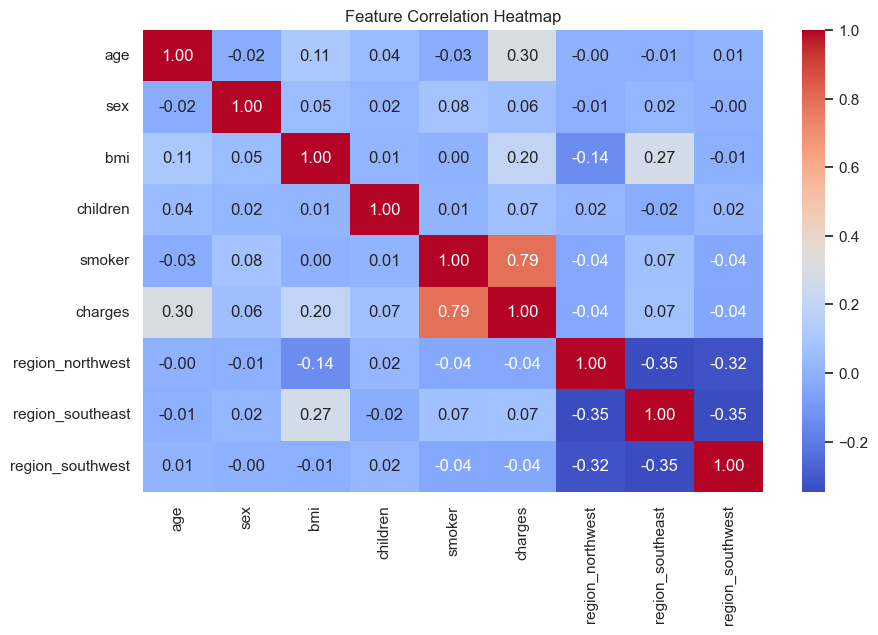

In [13]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

**Model Training**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model Training Complete!")

Model Training Complete!


**Model Performance Evaluation**

In [15]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head(5)
print("\nSample Predictions (Actual vs Predicted):")
print(comparison)


Model Evaluation Metrics:
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28

Sample Predictions (Actual vs Predicted):
           Actual     Predicted
764    9095.06825   8969.550274
887    5272.17580   7068.747443
890   29330.98315  36858.410912
1293   9301.89355   9454.678501
259   33750.29180  26973.173457


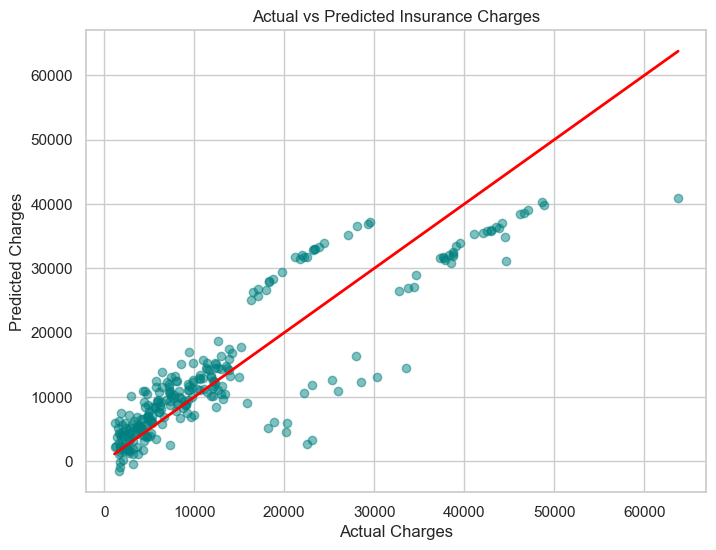

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()